<a href="https://colab.research.google.com/github/njwbilll/midterm-machine-learning/blob/main/3_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna mlflow kneed -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from kneed import KneeLocator
import mlflow
import mlflow.sklearn

print("✅ Semua library berhasil diimport!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/ML Dataset/'
df = pd.read_csv(BASE_PATH + 'clusteringmidterm.csv')

print(f"Shape: {df.shape}")
print(f"\nStatistik deskriptif:")
df.describe().T

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (8950, 18)

Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


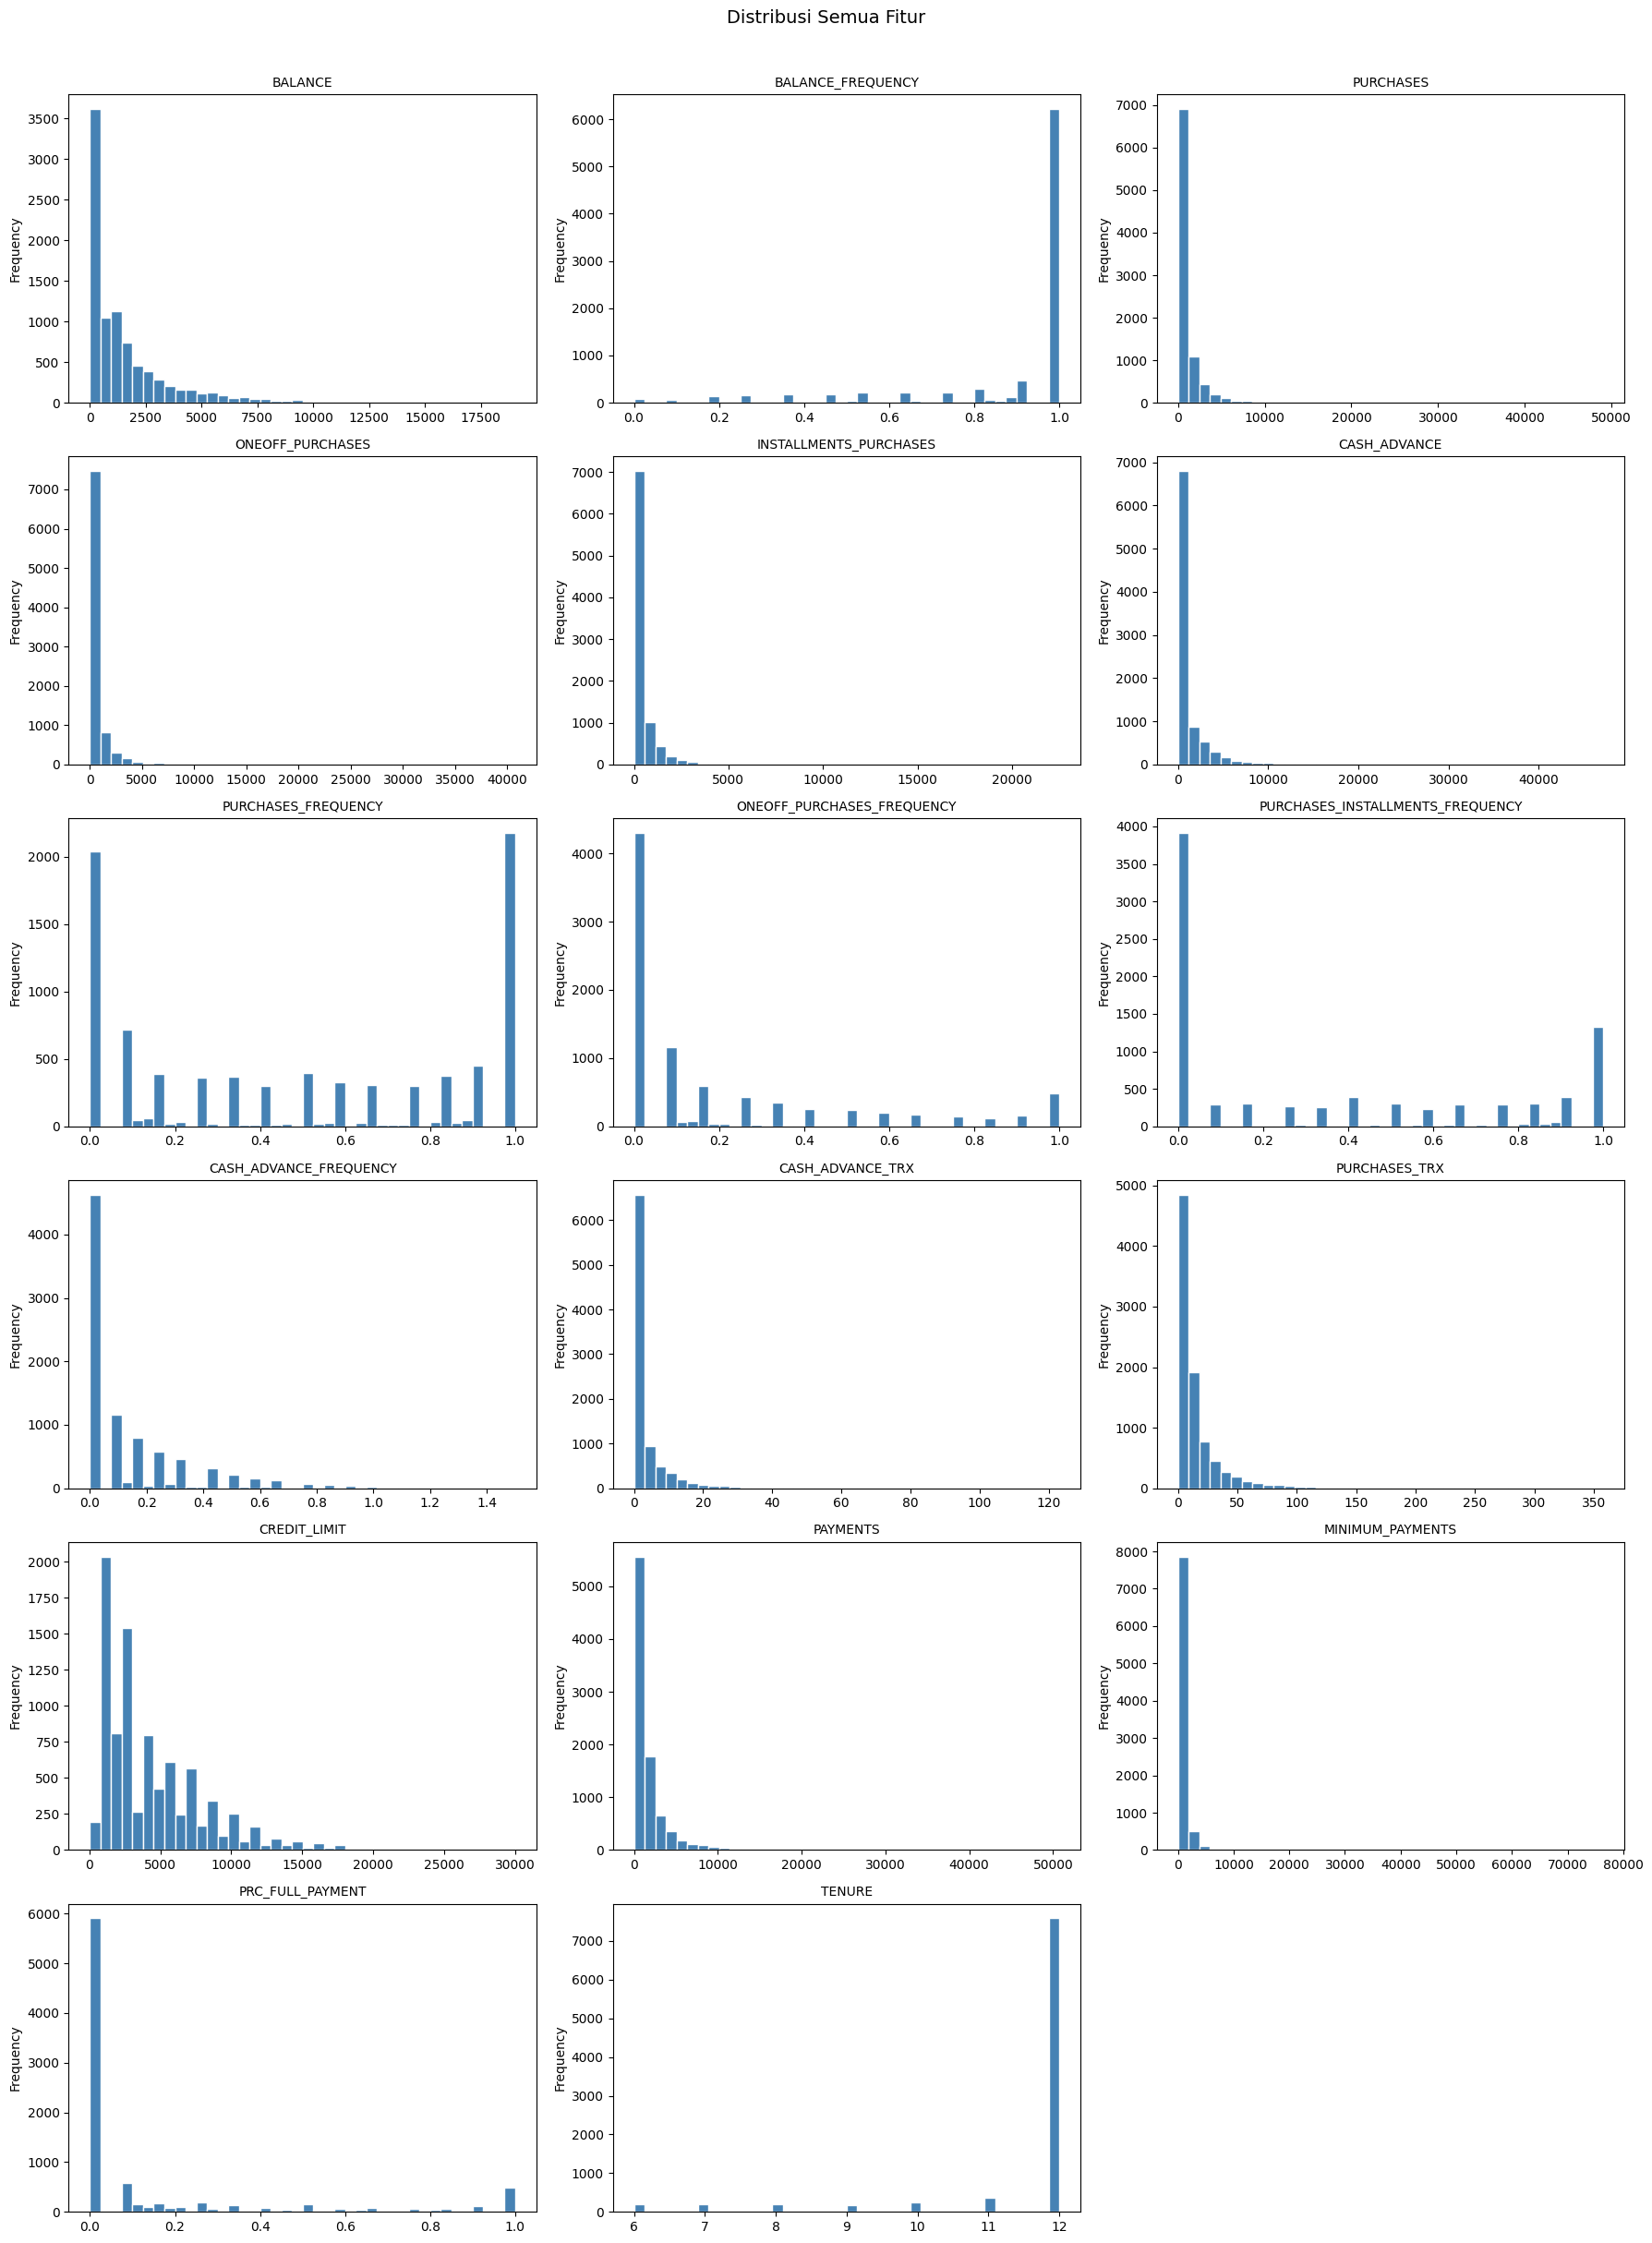

In [ ]:
# Drop CUST_ID untuk visualisasi
num_cols = df.drop(columns=['CUST_ID']).columns.tolist()

fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].plot(kind='hist', bins=40, ax=axes[i],
                 color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

# Hide sisa axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

1. Preprocessing Data
Pada tahap ini, melakukan pengisian nilai kosong (missing values) menggunakan median. Selain itu, Outlier Clipping juga dilakukan agar distribusi data tidak terlalu condong (skewed), yang sangat penting untuk performa algoritma K-Means.

In [ ]:
df_clean = df.copy()

# 1. Drop CUST_ID
df_clean.drop(columns=['CUST_ID'], inplace=True)

# 2. Isi missing values dengan median
df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median(), inplace=True)
df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median(), inplace=True)

print(f"Missing values setelah imputasi: {df_clean.isnull().sum().sum()}")

# 3. Handle outliers dengan clipping (IQR method)
for col in df_clean.columns:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

# 4. Feature engineering
df_clean['PURCHASE_TO_LIMIT']  = df_clean['PURCHASES'] / (df_clean['CREDIT_LIMIT'] + 1)
df_clean['PAYMENT_TO_BALANCE'] = df_clean['PAYMENTS'] / (df_clean['BALANCE'] + 1)
df_clean['CASH_TO_LIMIT']      = df_clean['CASH_ADVANCE'] / (df_clean['CREDIT_LIMIT'] + 1)

# 5. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print(f"✅ Shape setelah preprocessing: {df_clean.shape}")
print(f"Fitur total: {df_clean.columns.tolist()}")

Missing values setelah imputasi: 0
✅ Shape setelah preprocessing: (8950, 20)
Fitur total: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'PURCHASE_TO_LIMIT', 'PAYMENT_TO_BALANCE', 'CASH_TO_LIMIT']


2026/05/15 10:57:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 10:57:10 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 10:57:14 INFO mlflow.tracking.fluent: Experiment with name 'CustomerClustering_ML' does not exist. Creating a new experiment.


Menghitung optimal K...
  K=2 | Silhouette=0.2830 | DB=1.6401
  K=3 | Silhouette=0.2468 | DB=1.4843
  K=4 | Silhouette=0.1977 | DB=1.5960
  K=5 | Silhouette=0.1986 | DB=1.2837
  K=6 | Silhouette=0.1949 | DB=1.2701
  K=7 | Silhouette=0.2032 | DB=1.3501
  K=8 | Silhouette=0.2037 | DB=1.1975
  K=9 | Silhouette=0.1946 | DB=1.2987
  K=10 | Silhouette=0.1983 | DB=1.3038

📍 Elbow K  : 4
📍 Best Sil K: 2


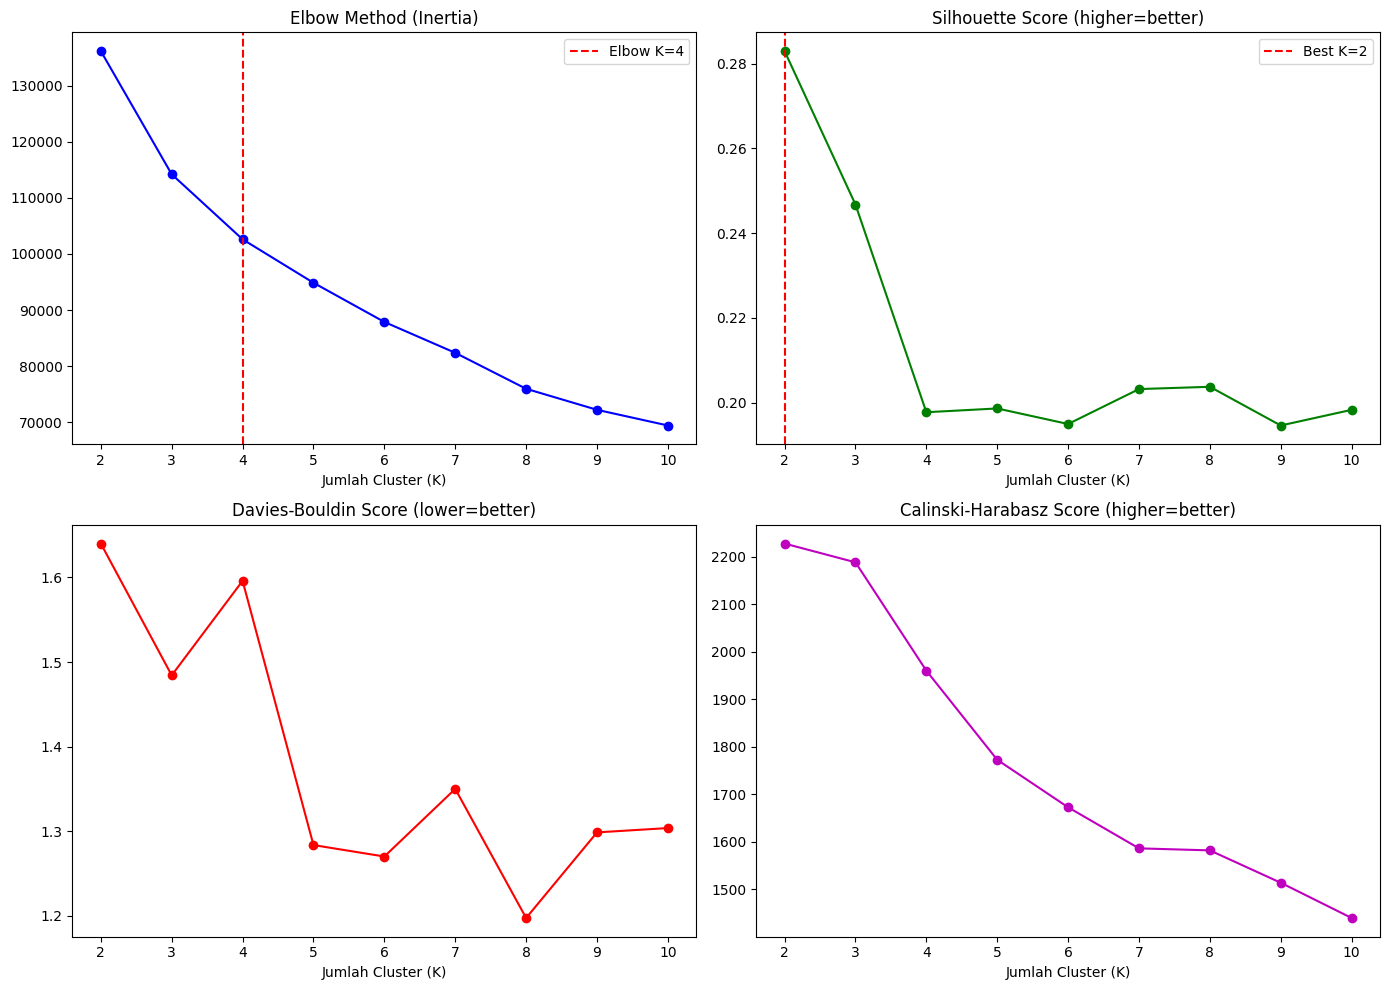

In [ ]:
mlflow.set_experiment("CustomerClustering_ML")

inertias   = []
sil_scores = []
db_scores  = []
ch_scores  = []
K_range    = range(2, 11)

print("Menghitung optimal K...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f"  K={k} | Silhouette={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f}")

# Auto-detect elbow
kl = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
best_k_elbow = kl.elbow
best_k_sil   = list(K_range)[np.argmax(sil_scores)]

print(f"\n📍 Elbow K  : {best_k_elbow}")
print(f"📍 Best Sil K: {best_k_sil}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(K_range, inertias, 'bo-')
axes[0,0].axvline(x=best_k_elbow, color='red', linestyle='--', label=f'Elbow K={best_k_elbow}')
axes[0,0].set_title('Elbow Method (Inertia)')
axes[0,0].set_xlabel('Jumlah Cluster (K)')
axes[0,0].legend()

axes[0,1].plot(K_range, sil_scores, 'go-')
axes[0,1].axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[0,1].set_title('Silhouette Score (higher=better)')
axes[0,1].set_xlabel('Jumlah Cluster (K)')
axes[0,1].legend()

axes[1,0].plot(K_range, db_scores, 'ro-')
axes[1,0].set_title('Davies-Bouldin Score (lower=better)')
axes[1,0].set_xlabel('Jumlah Cluster (K)')

axes[1,1].plot(K_range, ch_scores, 'mo-')
axes[1,1].set_title('Calinski-Harabasz Score (higher=better)')
axes[1,1].set_xlabel('Jumlah Cluster (K)')

plt.tight_layout()
plt.show()

In [ ]:
# Pakai K terbaik dari silhouette
BEST_K = best_k_sil
print(f"Training KMeans dengan K={BEST_K}...")

with mlflow.start_run(run_name=f"KMeans_K{BEST_K}"):
    kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels_km)
    db  = davies_bouldin_score(X_scaled, labels_km)
    ch  = calinski_harabasz_score(X_scaled, labels_km)

    mlflow.log_param("model", "KMeans")
    mlflow.log_param("n_clusters", BEST_K)
    mlflow.log_metric("silhouette_score", sil)
    mlflow.log_metric("davies_bouldin_score", db)
    mlflow.log_metric("calinski_harabasz_score", ch)

    print(f"✅ KMeans K={BEST_K}")
    print(f"   Silhouette Score        : {sil:.4f}")
    print(f"   Davies-Bouldin Score    : {db:.4f}  (lower=better)")
    print(f"   Calinski-Harabasz Score : {ch:.4f}  (higher=better)")

df_clean['Cluster_KMeans'] = labels_km
print(f"\nDistribusi cluster:\n{pd.Series(labels_km).value_counts().sort_index()}")

Training KMeans dengan K=2...
✅ KMeans K=2
   Silhouette Score        : 0.2830
   Davies-Bouldin Score    : 1.6401  (lower=better)
   Calinski-Harabasz Score : 2227.8639  (higher=better)

Distribusi cluster:
0    2199
1    6751
Name: count, dtype: int64


In [ ]:
print(f"Training Agglomerative Clustering dengan K={BEST_K}...")

with mlflow.start_run(run_name=f"Agglomerative_K{BEST_K}"):
    agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
    labels_agg = agg.fit_predict(X_scaled)

    sil_agg = silhouette_score(X_scaled, labels_agg)
    db_agg  = davies_bouldin_score(X_scaled, labels_agg)
    ch_agg  = calinski_harabasz_score(X_scaled, labels_agg)

    mlflow.log_param("model", "AgglomerativeClustering")
    mlflow.log_param("n_clusters", BEST_K)
    mlflow.log_param("linkage", "ward")
    mlflow.log_metric("silhouette_score", sil_agg)
    mlflow.log_metric("davies_bouldin_score", db_agg)
    mlflow.log_metric("calinski_harabasz_score", ch_agg)

    print(f"✅ Agglomerative K={BEST_K}")
    print(f"   Silhouette Score        : {sil_agg:.4f}")
    print(f"   Davies-Bouldin Score    : {db_agg:.4f}")
    print(f"   Calinski-Harabasz Score : {ch_agg:.4f}")

df_clean['Cluster_Agg'] = labels_agg
print(f"\nDistribusi cluster:\n{pd.Series(labels_agg).value_counts().sort_index()}")

Training Agglomerative Clustering dengan K=2...
✅ Agglomerative K=2
   Silhouette Score        : 0.1833
   Davies-Bouldin Score    : 1.9596
   Calinski-Harabasz Score : 1833.9031

Distribusi cluster:
0    4815
1    4135
Name: count, dtype: int64


Explained variance: 50.4%


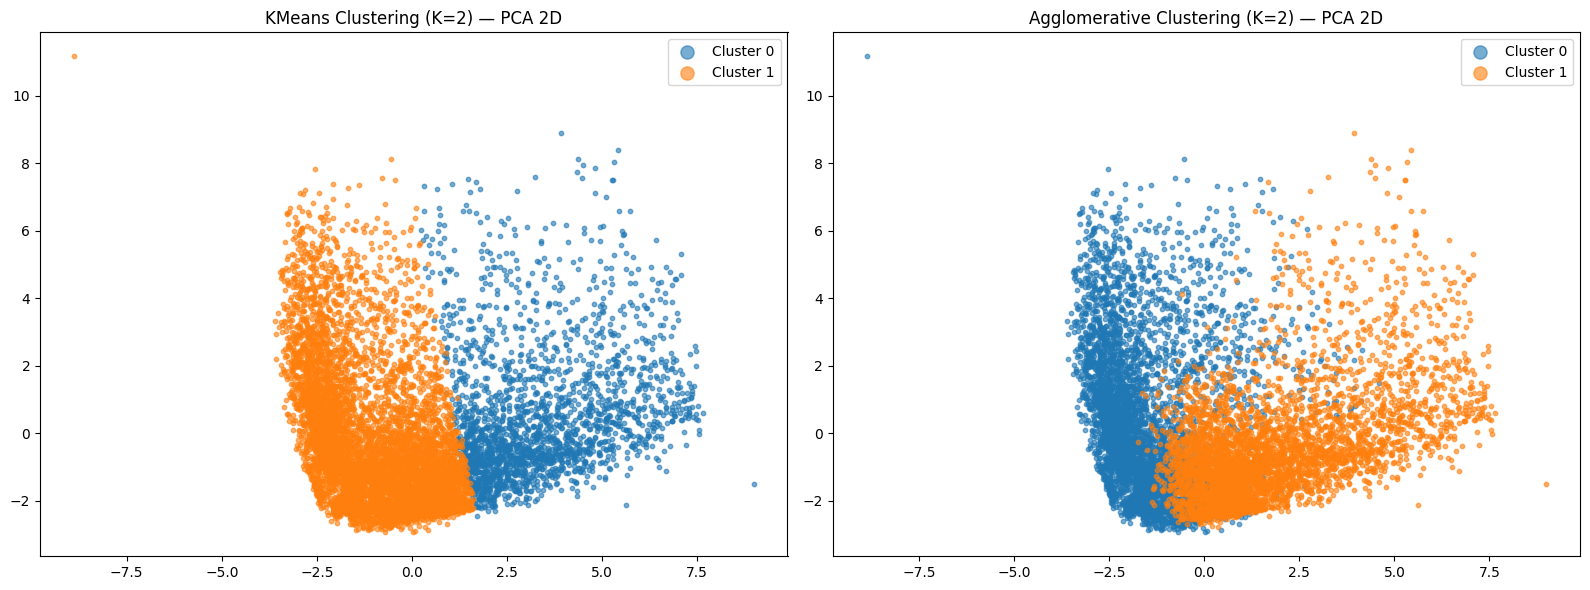

In [ ]:
# Reduksi dimensi ke 2D untuk visualisasi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Set1(np.linspace(0, 1, BEST_K))

# KMeans
for k in range(BEST_K):
    mask = labels_km == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=10, alpha=0.6, label=f'Cluster {k}')
axes[0].set_title(f'KMeans Clustering (K={BEST_K}) — PCA 2D')
axes[0].legend(markerscale=3)

# Agglomerative
for k in range(BEST_K):
    mask = labels_agg == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=10, alpha=0.6, label=f'Cluster {k}')
axes[1].set_title(f'Agglomerative Clustering (K={BEST_K}) — PCA 2D')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

=== PROFIL TIAP CLUSTER (rata-rata) ===
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE
Cluster                                                                                                                                                                                                                                                                                                               
0        1928.65               0.97    3123.16           1899.50                 1223.97        642.93                 0.91                        0.52                              0.70                    0.08              2.01          42.19       6384.18   3245.03           1109.98              0.27   11.81
1        1445.85           

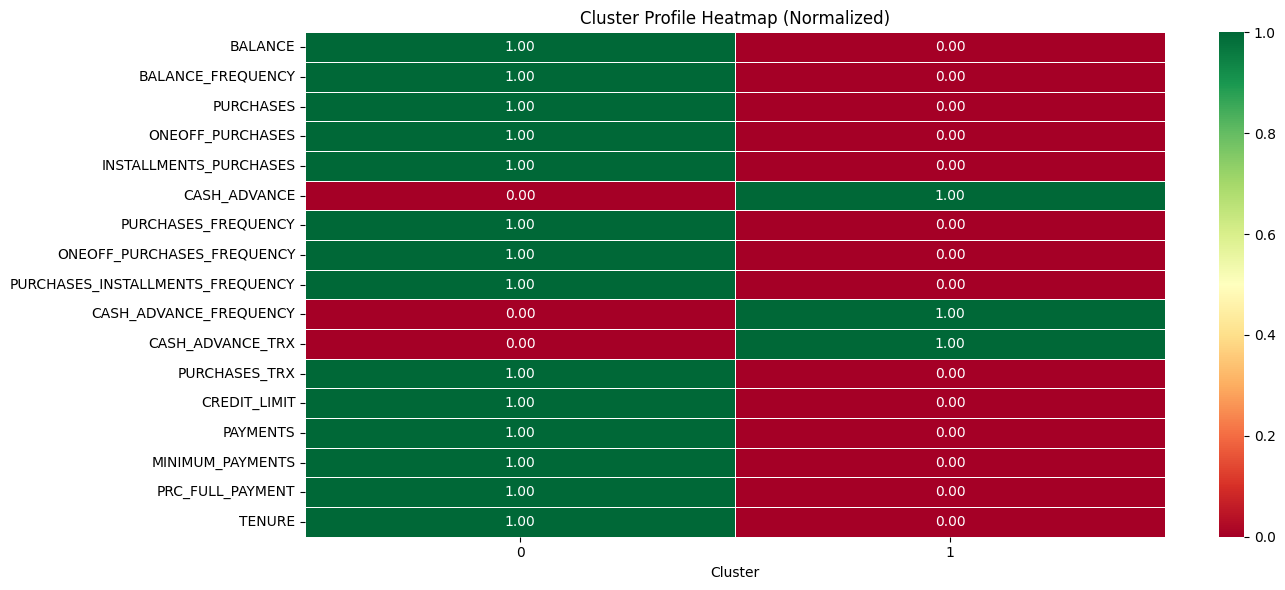

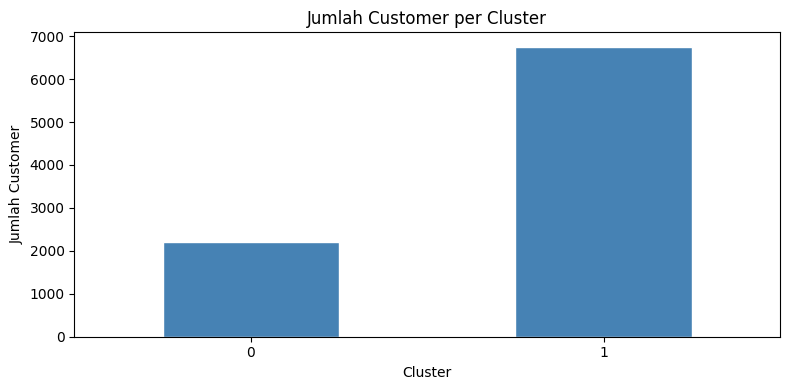

In [ ]:
# Pakai KMeans sebagai model final (biasanya lebih stabil)
df_original = df.copy()
df_original.drop(columns=['CUST_ID'], inplace=True)
df_original['CREDIT_LIMIT'].fillna(df_original['CREDIT_LIMIT'].median(), inplace=True)
df_original['MINIMUM_PAYMENTS'].fillna(df_original['MINIMUM_PAYMENTS'].median(), inplace=True)
df_original['Cluster'] = labels_km

# Profil tiap cluster
cluster_profile = df_original.groupby('Cluster').mean().round(2)
print("=== PROFIL TIAP CLUSTER (rata-rata) ===")
print(cluster_profile.to_string())

# Heatmap profil cluster
plt.figure(figsize=(14, 6))
# Normalize untuk heatmap
profile_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min())
sns.heatmap(profile_norm.T, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, cbar=True)
plt.title('Cluster Profile Heatmap (Normalized)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# Ukuran tiap cluster
cluster_sizes = pd.Series(labels_km).value_counts().sort_index()
cluster_sizes.plot(kind='bar', color='steelblue', edgecolor='white', figsize=(8, 4))
plt.title('Jumlah Customer per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== PERBANDINGAN MODEL CLUSTERING ===
        Model  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score
       KMeans          0.283002              1.640067              2227.863862
Agglomerative          0.183320              1.959574              1833.903108


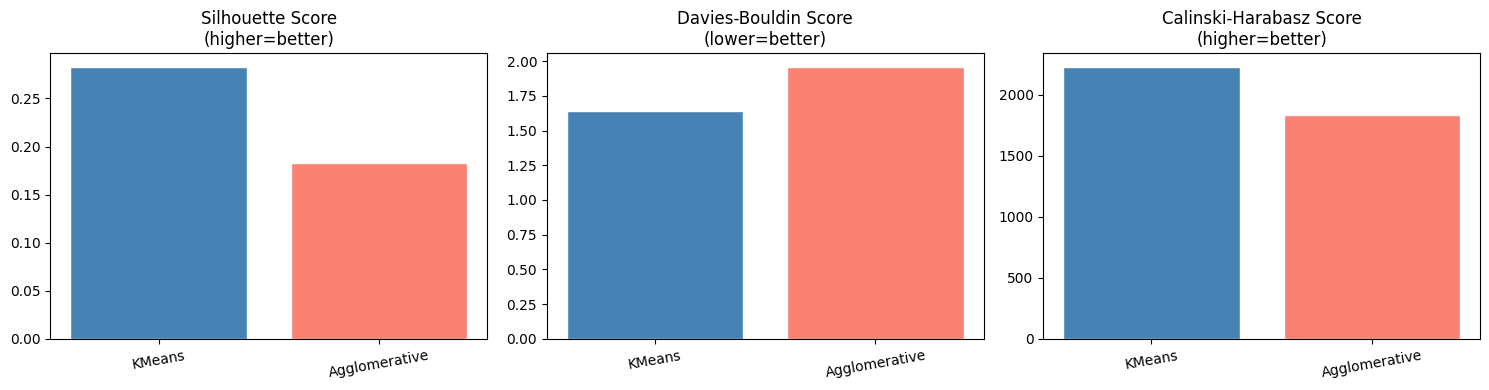

In [ ]:
# Tabel perbandingan
comparison = pd.DataFrame({
    'Model'                   : ['KMeans', 'Agglomerative'],
    'Silhouette Score'        : [sil, sil_agg],
    'Davies-Bouldin Score'    : [db, db_agg],
    'Calinski-Harabasz Score' : [ch, ch_agg]
})

print("=== PERBANDINGAN MODEL CLUSTERING ===")
print(comparison.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['Silhouette Score', 'Davies-Bouldin Score', 'Calinski-Harabasz Score']
colors  = ['steelblue', 'salmon']
notes   = ['higher=better', 'lower=better', 'higher=better']

for ax, metric, note in zip(axes, metrics, notes):
    ax.bar(comparison['Model'], comparison[metric],
           color=colors, edgecolor='white')
    ax.set_title(f'{metric}\n({note})')
    ax.set_xticklabels(comparison['Model'], rotation=10)

plt.tight_layout()
plt.show()

In [ ]:
import joblib, os

SAVE_PATH = '/content/drive/MyDrive/ML Dataset/models_clustering/'
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(kmeans,  SAVE_PATH + 'kmeans_model.pkl')
joblib.dump(agg,     SAVE_PATH + 'agglomerative_model.pkl')
joblib.dump(scaler,  SAVE_PATH + 'scaler.pkl')
joblib.dump(pca,     SAVE_PATH + 'pca.pkl')

# Simpan hasil cluster ke CSV
df_result = df[['CUST_ID']].copy()
df_result['Cluster_KMeans'] = labels_km
df_result['Cluster_Agg']    = labels_agg
df_result.to_csv(SAVE_PATH + 'cluster_results.csv', index=False)

print("✅ Semua model & hasil clustering tersimpan!")
print(df_result.head())

✅ Semua model & hasil clustering tersimpan!
  CUST_ID  Cluster_KMeans  Cluster_Agg
0  C10001               1            0
1  C10002               1            0
2  C10003               1            1
3  C10004               1            0
4  C10005               1            0
